# XOR con perceptrones (desde cero)
Este ejemplo muestra cómo construir la función XOR combinando perceptrones simples (NAND, OR, AND) sin librerías de ML.

In [39]:
import numpy as np

In [40]:
# Perceptrón simple: suma ponderada + sesgo, función escalón
def perceptron(x, w, b):
    # x: vector entrada (x1, x2)
    # w: vector de pesos (w1, w2)
    # b: sesgo (bias)
    # La salida es 1 si la suma ponderada + b > 0, sino 0.
    s = x[0]*w[0] + x[1]*w[1] + b
    return 1 if s > 0 else 0

EPOCHS = int(5)

def train_perceptron(X, y, lr=0.1, epochs=EPOCHS, tol=1e-6, seed=0):
    """
    Entrena un perceptrón usando la regla delta discreta (regla del perceptrón).
    - X: lista de tuplas de entrada [(x1,x2),...]
    - y: lista de etiquetas {0,1}
    - lr: learning rate (tamaño de paso)
    - epochs: número máximo de épocas
    - seed: semilla para inicializar pesos aleatorios reproducibles

    Retorna (w_list, b_float, épocas_usadas)
    """
    # Inicializador aleatorio reproducible
    rng = np.random.default_rng(seed)

    # Inicializar pesos y sesgo pequeños cerca de 0
    w = rng.normal(scale=0.01, size=2)
    b = float(rng.normal(scale=0.01))

    # Convertir a arrays para operaciones vectorizadas
    X_arr = np.array(X)
    y_arr = np.array(y)

    for epoch in range(int(epochs)):
        # Barajar los índices cada época para evitar orden fijo
        idx = rng.permutation(len(X_arr))
        errors = 0  # contador de errores en la época

        for i in idx:
            xi = X_arr[i]
            yi = y_arr[i]

            # Predicción actual: suma ponderada + sesgo
            s = float(np.dot(w, xi) + b)
            out = 1 if s > 0 else 0

            # Error: diferencia entre etiqueta y predicción
            err = yi - out

            # Si hay error ajustamos pesos y sesgo (regla perceptrón)
            if err != 0:
                # Actualización: w <- w + lr * err * x, b <- b + lr * err
                w += lr * err * xi
                b += lr * err
                errors += 1

        # Si en una época no hubo errores, convergió perfectamente
        if errors == 0:
            return w.tolist(), float(b), epoch+1

    # Si llega aquí, no convergió en el número máximo de épocas
    return w.tolist(), float(b), int(epochs)

# Datos (tabla de verdad)
''' 
X  Y | AND OR NAND XOR
0  0 | 0   0   1    0
0  1 | 0   1   1    1
1  0 | 0   1   1    1
1  1 | 1   1   0    0
'''
X_data = [(0,0), (0,1), (1,0), (1,1)]
AND_y = [0,0,0,1]
OR_y  = [0,1,1,1]
NAND_y= [1,1,1,0]

# Entrenar perceptrones para AND, OR y NAND usando la función anterior
w_and, b_and, ep_and = train_perceptron(X_data, AND_y, lr=0.1, epochs=EPOCHS, tol=1e-6)
w_or,  b_or,  ep_or  = train_perceptron(X_data, OR_y,  lr=0.1, epochs=EPOCHS, tol=1e-6)
w_nand,b_nand,ep_nand = train_perceptron(X_data, NAND_y,lr=0.1, epochs=EPOCHS, tol=1e-6)

# Mostrar pesos y número de épocas necesarias
print('AND learned w,b (epochs):', w_and, b_and, ep_and)
print('OR  learned w,b (epochs):', w_or,  b_or,  ep_or)
print('NAND learned w,b (epochs):', w_nand, b_nand, ep_nand)


# Redefinir funciones lógicas para usar los pesos aprendidos
def AND(x1, x2):
    # Usa el perceptrón con los pesos y sesgo aprendidos para AND
    return perceptron([x1, x2], w_and, b_and)

def OR(x1, x2):
    # Usa el perceptrón con los pesos y sesgo aprendidos para OR
    return perceptron([x1, x2], w_or, b_or)

def NAND(x1, x2):
    # Usa el perceptrón con los pesos y sesgo aprendidos para NAND
    return perceptron([x1, x2], w_nand, b_nand)


# XOR se compone como: XOR = AND( OR(x,y), NAND(x,y) )
def XOR(x1, x2):
    # Primero calculamos OR(x,y) y NAND(x,y), luego la AND entre esos resultados
    s1 = OR(x1, x2)
    s2 = NAND(x1, x2)
    return AND(s1, s2)


# Pruebas: imprimir la tabla de verdad usando las funciones aprendidas
inputs = [(0,0), (0,1), (1,0), (1,1)]
print('x1 x2 | AND OR NAND XOR')
for x1, x2 in inputs:
    print(x1, x2, '|', AND(x1,x2), OR(x1,x2), NAND(x1,x2), XOR(x1,x2))

AND learned w,b (epochs): [0.10125730221093396, 0.09867895136708699] -0.1935957734955672 5
OR  learned w,b (epochs): [0.10125730221093394, 0.09867895136708699] -0.09359577349556719 3
NAND learned w,b (epochs): [-0.09874269778906605, -0.10132104863291302] 0.10640422650443282 5
x1 x2 | AND OR NAND XOR
0 0 | 0 0 1 0
0 1 | 0 1 1 1
1 0 | 0 1 1 1
1 1 | 1 1 0 0


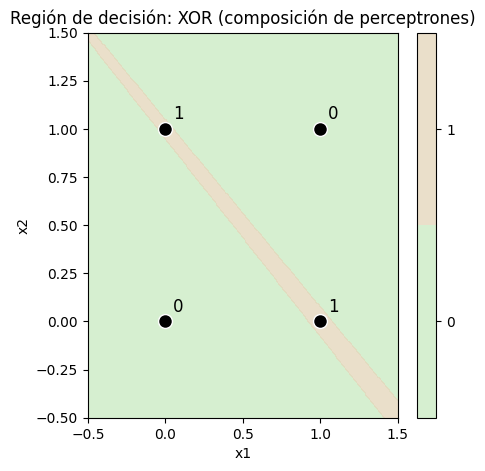

In [41]:
import matplotlib.pyplot as plt

# Crear una malla (grid) en el plano para evaluar la salida en cada punto
xx = np.linspace(-0.5, 1.5, 400)
X1, X2 = np.meshgrid(xx, xx)

# Vectorizamos la función XOR para aplicarla sobre arreglos (X1, X2)
vec_XOR = np.vectorize(XOR)
Z = vec_XOR(X1, X2)  # Z tendrá 0/1 según la salida XOR en cada punto

plt.figure(figsize=(5,5))

# Dibujar la región de decisión usando un mapa de colores
plt.contourf(X1, X2, Z, levels=[-0.5,0.5,1.5], cmap='Pastel1', alpha=0.8)
plt.colorbar(ticks=[0,1])

# Marcar los puntos de la tabla de verdad y anotar sus salidas
points = [(0,0),(0,1),(1,0),(1,1)]
for x1,x2 in points:
    # Dibujar un punto negro con borde blanco para destacar
    plt.scatter(x1, x2, c='k', s=100, edgecolors='w')
    # Escribir la salida esperada calculada por XOR justo al lado
    plt.text(x1+0.05, x2+0.05, str(XOR(x1,x2)), fontsize=12)

# Ajustes de ejes y etiquetas
plt.xlim(-0.5,1.5)
plt.ylim(-0.5,1.5)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Región de decisión: XOR (composición de perceptrones)')
plt.show()
